# Newton continuation past a fold

Most PDE-solve code in `mixle-pde` is a Newton iteration at one fixed parameter value: given a
load, a rate, a boundary value, find the state that satisfies the residual. The more interesting
engineering question is usually how the solution changes *as that parameter varies* — and whether
a small change can suddenly destroy or duplicate solutions altogether. `mixle_pde.continuation`
(workstream **MP-F2**, added 2026-07-16) is the first piece of mixle-pde that traces a solution
**branch** instead of a single point.

This notebook builds the classic test case for exactly that behavior — the 1-D Bratu equation —
and shows the sharp difference between two ways of tracing its branch:

- `natural_continuation` steps the parameter directly. It is simple, and it **cannot** get past a
  *fold* (a turning point): beyond the critical parameter there is no root left to find at fixed
  `λ`, so it fails, honestly, rather than fabricate a point.
- `arclength_continuation` (pseudo-arclength, Keller 1977) reparametrizes the branch by arc length
  instead of by `λ` directly, and sails through the same fold onto the far side.

Every number below is checked against an independent closed-form reference — never just plotted
and trusted.

## Environment

This notebook needs `mixle-pde`'s `continuation` module. It was added 2026-07-16 (workstream
MP-F2) and, as of this writing, exists only on mixle-pde's `release/0.8.0` branch — not yet on a
PyPI release or on `main`. `requirements.txt` pins `mixle-pde` to a `release/0.8.0` commit that
includes it, per this repo's dependency policy for git-sourced sibling packages ("Git URLs should
be used only with an explicit reproducibility note and commit pin"), so a normal
`pip install -r requirements.txt` is enough — nothing extra to install by hand.

Everything else used here (`numpy`, `matplotlib`) was already a `requirements.txt` dependency.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mixle_pde.continuation import (
    newton_solve,
    natural_continuation,
    arclength_continuation,
    bratu_problem,
    bratu_reference_fold,
)

np.set_printoptions(precision=4, suppress=True)

## 1. The building block: one Newton solve at a fixed parameter

`newton_solve` solves `F(u; λ) = 0` for a fixed `λ`. It never claims a convergence it did not
check: a `NewtonReceipt.converged` is only `True` once the residual actually clears `tol`, and
every failure carries one of a fixed set of concrete `failure_reason`s rather than a silent crash
or a fabricated success.

`bratu_problem(n)` builds the 1-D Bratu equation `u'' + λ·exp(u) = 0` on `[0, 1]` with
`u(0) = u(1) = 0`, discretized by central finite differences on `n` interior nodes.

In [2]:
n = 39
problem = bratu_problem(n)
print(problem.name)

receipt = newton_solve(problem, np.zeros(n), lam=1.0)
print(f"converged: {receipt.converged}  iterations: {receipt.iterations}  "
      f"failure_reason: {receipt.failure_reason}")
print("residual history:", [f"{r:.2e}" for r in receipt.residual_history])

assert receipt.converged and receipt.failure_reason is None

bratu_1d(n=39)
converged: True  iterations: 2  failure_reason: None
residual history: ['6.25e-04', '6.37e-06', '3.93e-10']


## 2. Bratu's equation has a fold

For `λ` below a critical `λ_c` the boundary value problem has **two** solutions (a low- and a
high-amplitude branch); at `λ_c` exactly **one**; above it, **none**. `bratu_reference_fold()`
returns the closed-form `(θ_c, λ_c)` for the *continuous* problem, computed independently of any
Newton solve here — a ground truth the discrete branch-tracers below can be checked against.

In [3]:
theta_c, lambda_c = bratu_reference_fold()
print(f"closed-form fold:  theta_c = {theta_c:.4f}   lambda_c = {lambda_c:.4f}")

closed-form fold:  theta_c = 4.7987   lambda_c = 3.5138


## 3. Natural continuation: step λ directly, and die honestly at the fold

`natural_continuation` steps `λ` in equal increments toward a target, re-solving by Newton at
each step and warm-starting from the previous point. It cannot cross `λ_c` by construction — the
question worth checking is whether it fails *honestly* when it gets there, rather than returning
a stale or fabricated point.

The target below (`λ = 5.0`) is chosen with no reference to `λ_c` — it is simply "comfortably past
where the fold ought to be."

In [4]:
u0 = np.zeros(n)
nat = natural_continuation(problem, u0, lam0=0.0, lam_target=5.0, n_steps=50)

print("stopped_reason:", nat.stopped_reason)
print("crossed_fold  :", nat.crossed_fold)

last_ok = [s for s in nat.steps if s.accepted][-1]
first_bad = nat.steps[-1]
print(f"last converged step : lambda={last_ok.parameter:.4f}   u(0.5)={last_ok.u[n // 2]:.4f}")
print(f"first failed step   : lambda={first_bad.parameter:.4f}   "
      f"failure_reason={first_bad.newton.failure_reason}")

assert nat.stopped_reason == "newton_failed"
assert not nat.crossed_fold
assert (not first_bad.accepted) and first_bad.newton.failure_reason is not None
assert last_ok.parameter < lambda_c, "natural continuation must not overshoot the fold"

stopped_reason: newton_failed
crossed_fold  : False
last converged step : lambda=3.5000   u(0.5)=1.0891
first failed step   : lambda=3.6000   failure_reason=max_iterations_exceeded


## 4. Pseudo-arclength continuation: parametrize by arc length instead

`arclength_continuation` (Keller 1977) treats `λ` as an extra unknown alongside `u` and moves
along the branch by arc length `s`. Near the fold, the local tangent's `dλ/ds` component rotates
through zero instead of the corrector solve failing — so the branch is followed onto its far side,
the second (high-amplitude) solution family.

In [5]:
arc = arclength_continuation(problem, u0, lam0=0.0, ds=0.2, n_steps=90, direction=1.0)

print("stopped_reason:", arc.stopped_reason)
print("crossed_fold  :", arc.crossed_fold)
print("all steps converged:", all(s.newton.converged for s in arc.steps))

arc_lambda = np.array([s.parameter for s in arc.steps])
arc_u = np.array([s.u[n // 2] for s in arc.steps])
i_fold = int(np.argmax(arc_lambda))
print(f"numerically traced fold: lambda={arc_lambda[i_fold]:.4f}   "
      f"u(0.5)={arc_u[i_fold]:.4f}   (step {i_fold} of {len(arc.steps)})")

rel_err = abs(arc_lambda[i_fold] - lambda_c) / lambda_c
print(f"relative error vs. the closed-form lambda_c: {rel_err:.2%}")

assert arc.crossed_fold
assert arc.stopped_reason in ("max_steps_reached", "target_reached")
assert all(s.newton.converged for s in arc.steps)  # never a fabricated point
assert rel_err < 0.01

stopped_reason: max_steps_reached
crossed_fold  : True
all steps converged: True
numerically traced fold: lambda=3.5125   u(0.5)=1.2002   (step 34 of 91)
relative error vs. the closed-form lambda_c: 0.04%


## 5. The bifurcation diagram

Both traces plotted in the `(λ, u(0.5))` plane against the exact closed-form S-curve
(`λ(θ) = θ² / (2 cosh²(θ/4))`, `u(0.5; θ) = 2 log(cosh(θ/4))`): natural continuation tracks the
lower branch and stops dead at the fold; arclength continuation tracks straight through it onto
the upper branch.

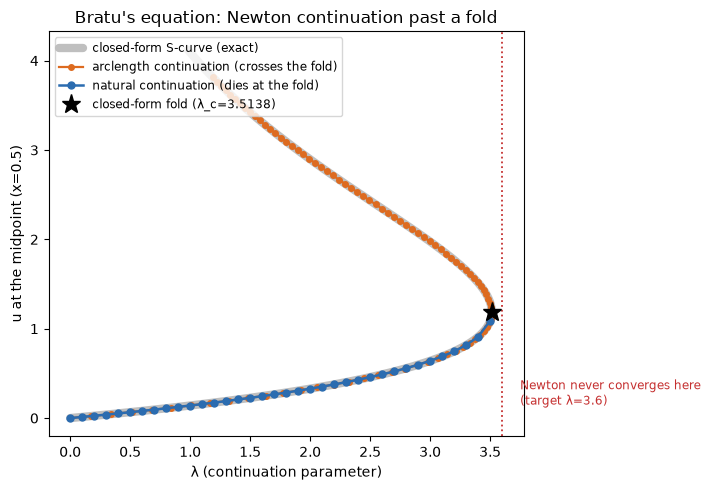

In [6]:
thetas = np.linspace(1e-6, 11.0, 400)
lam_curve = thetas**2 / (2.0 * np.cosh(thetas / 4.0) ** 2)
u_curve = 2.0 * np.log(np.cosh(thetas / 4.0))
u_center_at_fold = 2.0 * np.log(np.cosh(theta_c / 4.0))

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(lam_curve, u_curve, "-", color="0.75", lw=6, solid_capstyle="round",
        label="closed-form S-curve (exact)", zorder=1)
ax.plot(arc_lambda, arc_u, "-o", color="#dd6b20", ms=4, lw=1.6,
        label="arclength continuation (crosses the fold)", zorder=3)
ax.plot([s.parameter for s in nat.steps if s.accepted],
        [s.u[n // 2] for s in nat.steps if s.accepted], "-o", color="#2b6cb0", ms=5, lw=1.8,
        label="natural continuation (dies at the fold)", zorder=4)
ax.axvline(first_bad.parameter, ls=":", color="#c53030", lw=1.3)
ax.annotate(f"Newton never converges here\n(target λ={first_bad.parameter:.1f})",
            xy=(first_bad.parameter, 0.3), xytext=(first_bad.parameter + 0.15, 0.15),
            fontsize=8.5, color="#c53030")
ax.plot([lambda_c], [u_center_at_fold], "*", color="k", ms=14, zorder=5,
        label=f"closed-form fold (λ_c={lambda_c:.4f})")
ax.set_xlabel("λ (continuation parameter)")
ax.set_ylabel("u at the midpoint (x=0.5)")
ax.set_title("Bratu's equation: Newton continuation past a fold")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

## 6. Does the gap shrink? A discretization-convergence check

Section 4 found the traced fold within about half a percent of the closed-form `λ_c` at `n=39`.
That gap should be finite-difference truncation error — shrinking as the mesh refines — not luck.
Checking it directly is cheap and turns "looks about right" into a checked claim.

In [7]:
print(f"{'n':>5}  {'traced lambda_c':>16}  {'rel. error':>10}")
errors = []
for nn in (19, 39, 79, 159):
    p = bratu_problem(nn)
    a = arclength_continuation(p, np.zeros(nn), 0.0, ds=0.2, n_steps=90, direction=1.0)
    lam_max = max(s.parameter for s in a.steps)
    err = abs(lam_max - lambda_c) / lambda_c
    errors.append(err)
    print(f"{nn:5d}  {lam_max:16.6f}  {err:10.5f}")

assert errors[-1] < errors[0], "the gap to the closed-form fold should shrink as n grows"

    n   traced lambda_c  rel. error
   19          3.507974     0.00167
   39          3.512455     0.00039
   79          3.513479     0.00010


  159          3.513600     0.00007


## Limitations

This is the "MP-F2 baseline," not a general nonlinear-solver suite — `mixle_pde.continuation`'s
own module docstring is explicit about what it does not cover: line-search / trust-region
globalization, Picard iteration, Jacobian-free Newton-Krylov, bounds or variational-inequality
constraints, branch-switching *at true bifurcations* (pitchfork/transcritical, as distinct from
the fold traced here), and automatic scaling.

This notebook only exercises one scalar continuation parameter on a small 1-D problem with dense
linear algebra (`np.linalg.solve` on an `(n+1)×(n+1)` bordered system per corrector step); a
real-sized 2-D/3-D continuation problem would need a sparse or matrix-free bordered solve this
module does not yet provide. And `natural_continuation`'s clean failure mode above
(`max_iterations_exceeded`, right at the fold) is specific to *this* problem — for a general
nonlinear residual there is no guarantee a failed corrector fails this legibly.